In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(10):
        if (cur / "DATA" / "processed" / "master_df.parquet").exists():
            return cur
        if (cur / ".git").exists():
            return cur
        cur = cur.parent
    raise RuntimeError("Could not find repo root")

project_root = find_repo_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.regimes.features import build_regime_features, validate_stationarity
from src.diagnostics.stationarity import run_stationarity_suite

RESULTS_DIR = project_root / "results"
RESULTS_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_parquet(project_root / "DATA" / "processed" / "master_df.parquet").sort_index()

### Build Regime Features
Features are explained as:
1. `move_chg` 1 day differenced `MOVE Index` values, reflects change in volatility of U.S. Treasury Futures
2. `dxy_chg` 1 day differenced `BBDXY Index` values, reflects change in dollar spot index (performance of a basket of 10 leading global currencies against U.S. dollar)
4. `macro_surprise`. PC1 of `Citi Surprise Index` for EUR and US, which quantifies the difference between official economic results and forecasts.
5. `curve_signal`. PC1 of the 2 year-10 year spreads for USD, EUR, AUD, JPY. Which are the rate pairs we will be trading on. This provides global long-short term rate behaviour.

Features are shifted forward by 1 to prevent lookahead bias.

Observations: Earliest data without null values starts from 2005 onwards

Implications: No effect on statistical tests, proceed as normal

In [3]:
regime_features = build_regime_features(
    df,
    start_date='2000-01-01',
    zscore_window=252,
    include_fx_vol=True,
    include_curve_slopes=True
)


In [4]:
list(regime_features.columns)

['move_chg',
 'vix_chg',
 'dxy_chg',
 'cesi_usd_zscore',
 'cesi_eur_zscore',
 'cesi_jpy_zscore',
 'cesi_aud_zscore',
 'eurusd_vol_chg',
 'usdjpy_vol_chg',
 'us_2s10s_chg',
 'eur_2s10s_chg',
 'jpy_2s10s_chg',
 'aud_2s10s_chg']

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

regime_factors = pd.DataFrame(index=regime_features.index)

def extract_factor_pc1(df_subset: pd.DataFrame, name: str) -> pd.Series:
    """
    Extract first principal component from a subset of features.
    """
    # Standardize within this subset
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df_subset.dropna())
    
    # Extract PC1
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(scaled).flatten()
    
    print(f"{name}: PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
    
    return pd.Series(pc1, index=df_subset.dropna().index, name=name)


# Curve Signal PC1 (from all curve slopes)
curve_features = regime_features[['us_2s10s_chg', 'eur_2s10s_chg', 'jpy_2s10s_chg', 'aud_2s10s_chg']]
regime_features['curve_signal'] = extract_factor_pc1(curve_features, 'Curve Signal')

# Macro Surprise
macro_surprise = regime_features[['cesi_usd_zscore', 'cesi_eur_zscore', 'cesi_jpy_zscore', 'cesi_aud_zscore']]
regime_features['macro_surprise'] = extract_factor_pc1(macro_surprise, 'Macro Surprise')

Curve Signal: PC1 explains 36.2% of variance
Macro Surprise: PC1 explains 32.6% of variance


In [6]:
regime_features = regime_features[['move_chg', 'dxy_chg','curve_signal', 'macro_surprise']]
regime_features = regime_features.dropna()
regime_features

,move_chg,dxy_chg,curve_signal,macro_surprise
date,,,,
2005-01-06,9.90,0.15,-0.111188,0.081695
2005-01-07,-0.80,6.45,0.825629,0.102421
2005-01-10,-0.02,2.07,-0.594115,-0.057378
2005-01-11,-13.37,-2.53,-0.568648,0.014037
2005-01-12,-1.16,-4.02,-0.704281,0.231727
...,...,...,...,...
2025-12-22,-0.60,2.69,0.879816,1.679693
2025-12-23,2.29,-4.28,0.522242,1.572792
2025-12-24,-0.53,-3.98,-1.305039,1.739284


### Stationarity Test
Routine Check for Stationarity in the Feature set

Observations: All of the features are I(0) stationary.

Implications: Proceed as per normal.

In [7]:
stationarity_results = run_stationarity_suite(regime_features, alpha=0.05)

/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relativ

In [8]:
print("\n------Stationarity Test Results------")
print(stationarity_results[['column', 'nobs', 'adf_p', 'kpss_p', 'label']])

non_stationary = stationarity_results[stationarity_results['label'].str.contains('I\(1\)', case=False, na=False)]

if len(non_stationary) > 0:
    print("\n ------Non-stationary features------")
    print(non_stationary[['column', 'label']])
else:
    print("\n All features are stationary I(0)")


------Stationarity Test Results------
           column  nobs         adf_p  kpss_p              label
2    curve_signal  4847  0.000000e+00     0.1  I(0) (stationary)
1         dxy_chg  4847  0.000000e+00     0.1  I(0) (stationary)
3  macro_surprise  4847  1.234486e-13     0.1  I(0) (stationary)
0        move_chg  4847  3.199935e-30     0.1  I(0) (stationary)

 All features are stationary I(0)


In [9]:
regime_features.describe().T

,count,mean,std,min,25%,50%,75%,max
move_chg,4847.0,-0.054125,4.249262,-39.980000,-1.795850,-0.200000,1.530500,38.490000
dxy_chg,4847.0,0.004285,4.538751,-27.600000,-2.555000,0.040000,2.560000,21.090000
curve_signal,4847.0,-0.004084,1.243328,-7.793373,-0.681850,-0.070742,0.650385,10.718697
macro_surprise,4847.0,0.005663,1.151385,-3.675331,-0.901086,0.132936,0.900432,2.878170


## Plots
### Volatility Plot
**Purpose**: Validate that volatility features capture rates and equity market stress episodes.

**Significance**:
- MOVE changes spike during bond market dislocations (funding stress, policy uncertainty, liquidity crises)
- Crises period confirm whether features align with known macro events.
- Relation to HMM: High volatility regimes should correspond to periods when cross-country rate relationships break down due to fragmented liquidity and divergent risk premia. Spikes will drive regime switches in the HMM.

**How to check**:
- Volatility spikes should occur during known macro events.


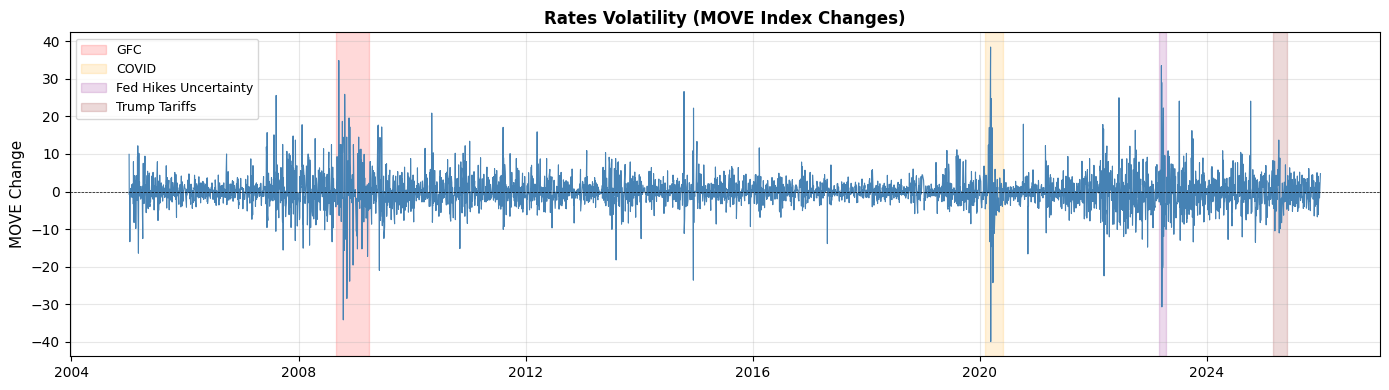

In [10]:
# Plot MOVE features with crisis periods
fig, axes = plt.subplots(figsize=(14,4), sharex=True)

# Notable crisis periods
crisis_periods = [
    ('2008-09-01', '2009-03-31', 'GFC', 'red'),
    ('2020-02-01', '2020-05-31', 'COVID', 'orange'),
    ('2023-03-01', '2023-04-10', 'Fed Hikes Uncertainty', 'purple'),
    ('2025-03-01', '2025-05-31', 'Trump Tariffs', 'maroon')
]

# MOVE changes
axes.plot(regime_features.index, regime_features['move_chg'], linewidth=0.8, color='steelblue')
axes.axhline(0, color='black', linewidth=0.5, linestyle='--')
axes.set_ylabel('MOVE Change', fontsize=11)
axes.set_title('Rates Volatility (MOVE Index Changes)', fontsize=12, fontweight='bold')
axes.grid(True, alpha=0.3)


# Highlight crisis periods
for start, end, label, color in crisis_periods:
    axes.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=color, label=label)

axes.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### DXY Changes and Macro Surprise

**Purpose**: Validate that USD stress and growth momentum capture macro regime shifts.

**Significance**:
- **DXY changes**: USD strength/weakness (funding stress, safe-haven flows)
- **Macro Surprise (PC1)**: Common component of US & EUR economic surprises
  - Positive values = synchronized growth acceleration (both regions beat expectations)
  - Negative values = synchronized slowdown (both regions miss expectations)
- ±1.96 thresholds mark extreme macro conditions (95% confidence)

**Relation to HMM**: 
- Macro surprises trigger central bank divergence and curve repricing
- Combined US+EUR surprises capture global growth regimes better than individual CESI

**How to check**:
- Do macro surprises spike during major growth shocks (GFC, COVID)?

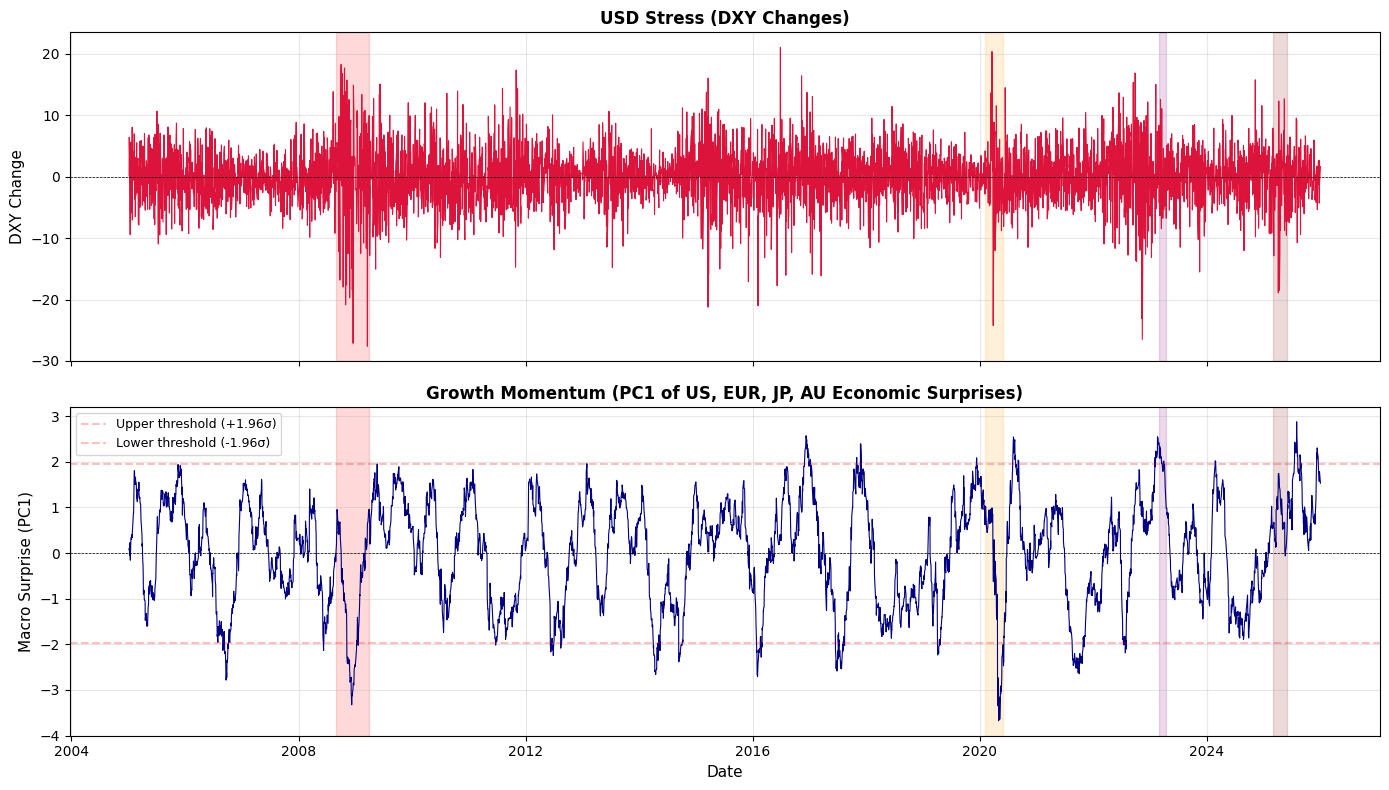

In [11]:
# Plot USD stress and macro surprise (factorized features)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# DXY changes 
axes[0].plot(regime_features.index, regime_features['dxy_chg'], linewidth=0.8, color='crimson')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('DXY Change', fontsize=11)
axes[0].set_title('USD Stress (DXY Changes)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Macro Surprise (PC1 of CESI USD + EUR)
axes[1].plot(regime_features.index, regime_features['macro_surprise'], linewidth=0.8, color='navy')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Macro Surprise (PC1)', fontsize=11)
axes[1].set_title('Growth Momentum (PC1 of US, EUR, JP, AU Economic Surprises)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Add significance thresholds for macro surprise
# For PC1, ±1.96 std from mean indicates extreme macro conditions
axes[1].axhline(y=1.96, color='r', linestyle='--', alpha=0.25, label='Upper threshold (+1.96σ)')
axes[1].axhline(y=-1.96, color='r', linestyle='--', alpha=0.25, label='Lower threshold (-1.96σ)')

# Highlight crisis periods
for start, end, label, color in crisis_periods:
    for ax in axes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=color)

axes[1].legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### Curve Signal (PC1)

**Purpose**: Validate that global curve dynamics capture regime shifts (recession vs reflation).

**Significance**:
- **Curve Signal (PC1)**: Common component across US, EUR, JPY, AUD 2s10s slope changes
  - Positive values = synchronized curve steepening (global reflation/easing expectations)
  - Negative values = synchronized curve flattening (global recession fears/tightening)
- Captures coordinated central bank policy expectations across major economies
- ±1.96 thresholds mark extreme curve movements

**Relation to HMM**: 
- Curve inversions/steepening define distinct regimes where cross-country spreads behave differently
- Global curve signal better than individual country slopes for identifying macro regimes

**How to check**:
- Does curve flatten during tightening cycles (2006-07, 2022-23)?
- Does curve steepen during easing cycles (2008-09, 2020)?

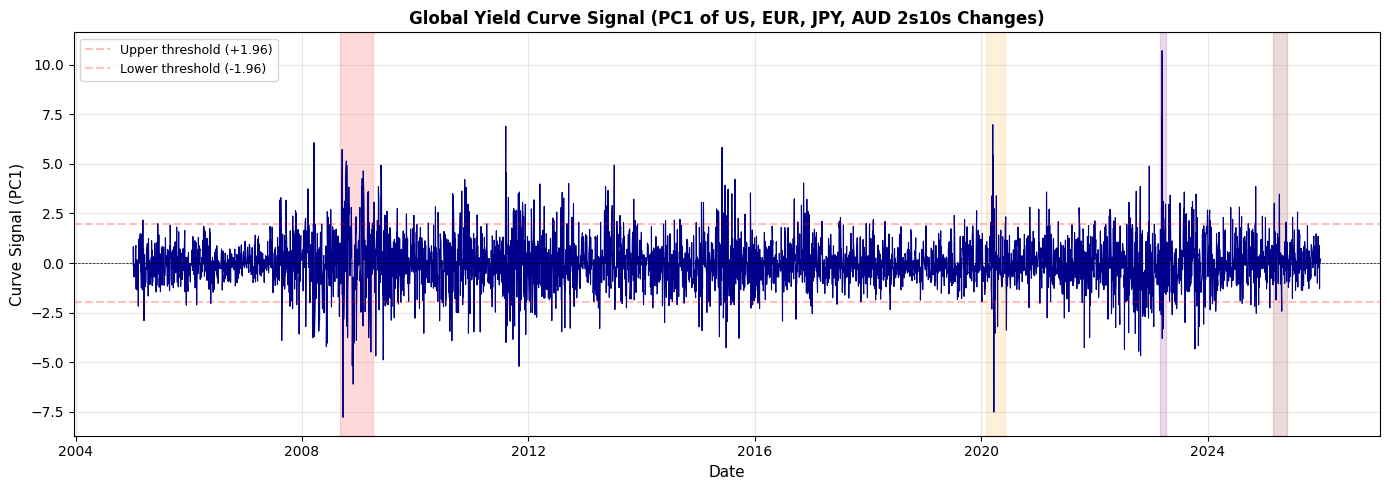


Interpretation:
  Positive curve_signal → Global curves steepening (reflation, easing expectations)
  Negative curve_signal → Global curves flattening (recession fears, tightening)


In [12]:
# Plot Curve Signal (PC1 of all yield curve slopes)
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(regime_features.index, regime_features['curve_signal'], 
        linewidth=0.8, color='darkblue')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_ylabel('Curve Signal (PC1)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_title('Global Yield Curve Signal (PC1 of US, EUR, JPY, AUD 2s10s Changes)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add significance thresholds
ax.axhline(y=1.96, color='r', linestyle='--', alpha=0.25, label='Upper threshold (+1.96)')
ax.axhline(y=-1.96, color='r', linestyle='--', alpha=0.25, label='Lower threshold (-1.96)')

# Highlight crisis periods
for start, end, label, color in crisis_periods:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=color)

ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Interpretation note
print("\nInterpretation:")
print("  Positive curve_signal → Global curves steepening (reflation, easing expectations)")
print("  Negative curve_signal → Global curves flattening (recession fears, tightening)")

### Regime Feature Correlation Matrix
**Purpose**: Diagnose multicollinearity and validate feature independence.

**Significance**:
- Moderate correlations (0.3-0.6) are expected (e.g., MOVE-VIX both reflect risk aversion)
- High correlations (>0.8) suggest redundancy → one feature is sufficient, drop the other
- Low correlations (<0.3) confirm features capture distinct regime dimensions
- Relation to HMM:
    - HMM with Gaussian emissions can handle correlated features (full covariance matrix), but extreme multicollinearity degrades numerical stability
    - Uncorrelated features ensure each contributes unique information about regime state


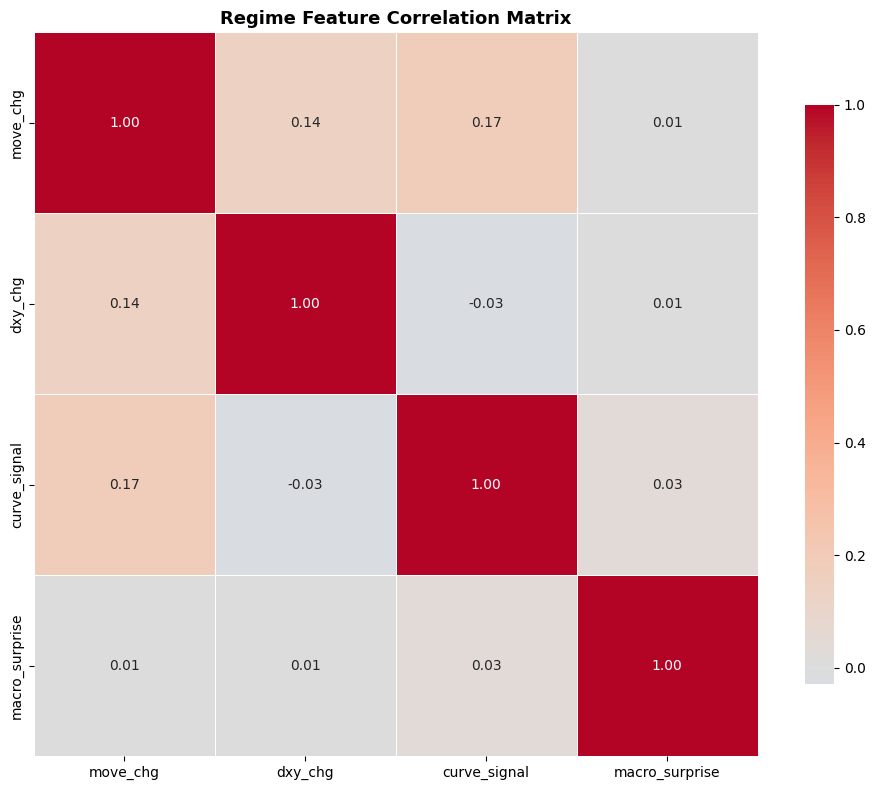

In [13]:
# Correlation heatmap
corr = regime_features.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Regime Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Save feature matrix
output_path = RESULTS_DIR / "regime_features.csv"
regime_features.to_csv(output_path)
# print(f"\n Saved: {output_path}")

# Save stationarity results
stationarity_path = RESULTS_DIR / "regime_features_stationarity.csv"
stationarity_results.to_csv(stationarity_path, index=False)
# print(f"Saved: {stationarity_path}")